# Imports & bestanden lezen

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt

projecturen = pd.read_excel('export_projecturen.xlsx')
werknemers = pd.read_excel('export_werknemers.xlsx')
Project_budget = pd.read_csv('Data_1/projects and budgets 2025.csv')

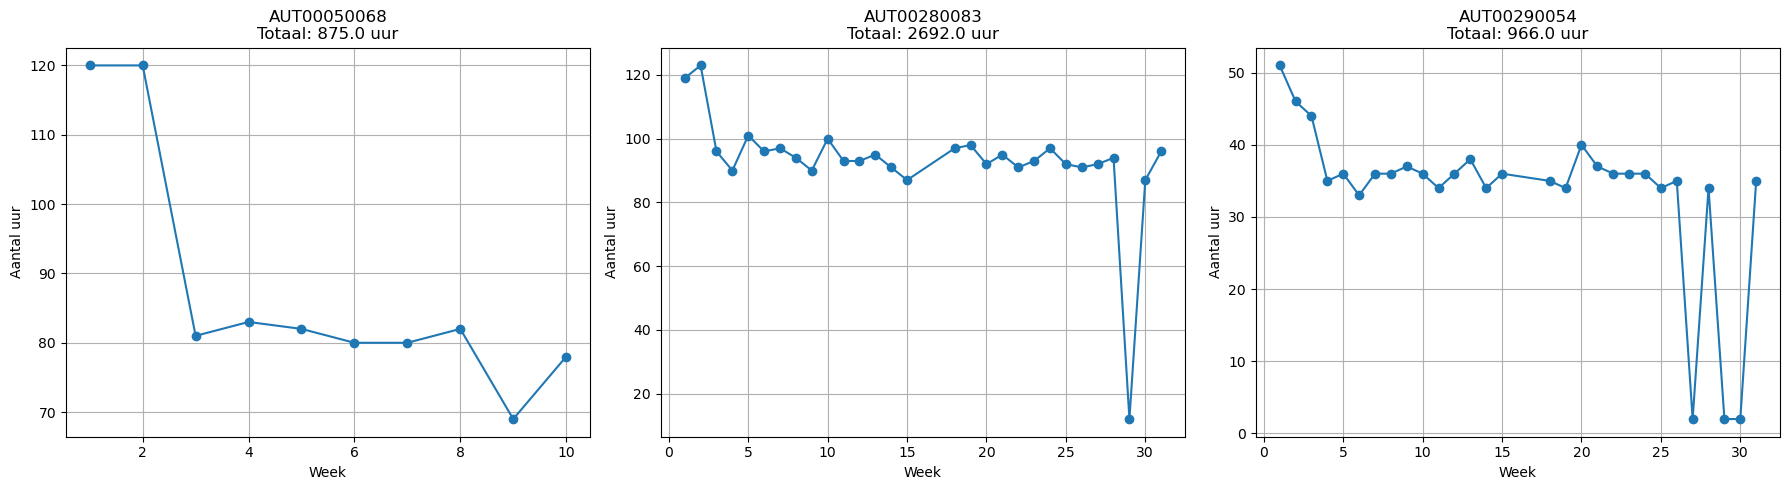

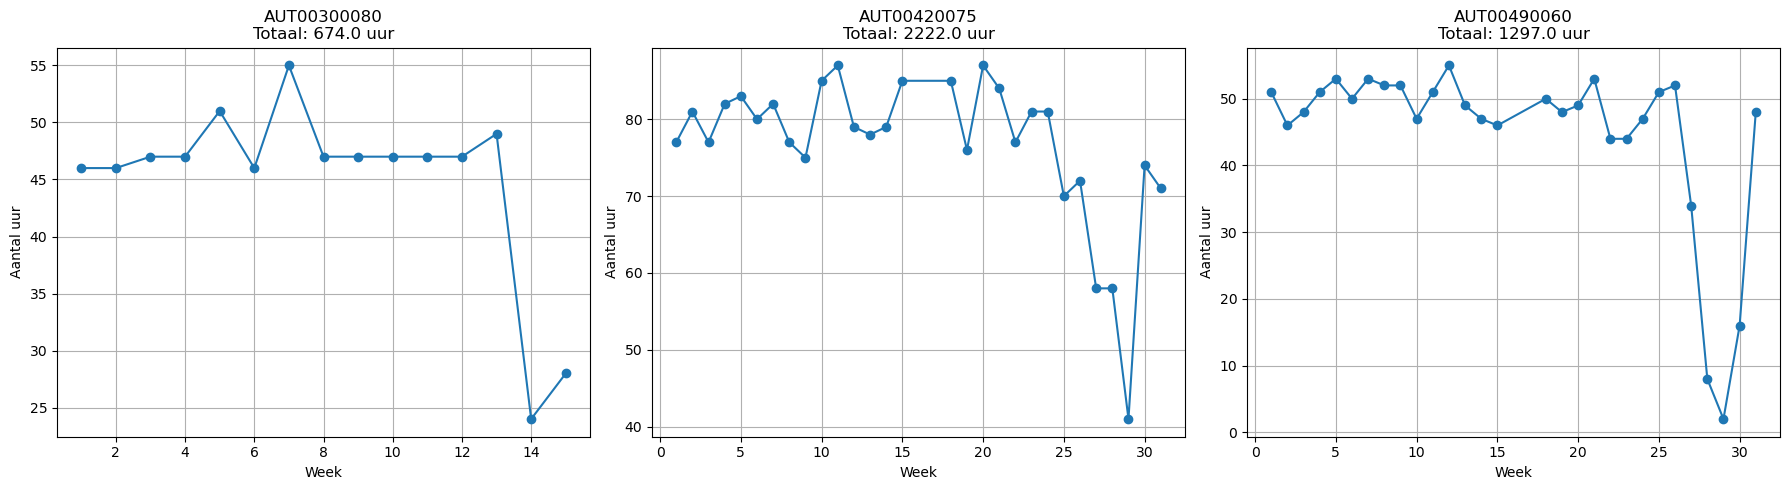

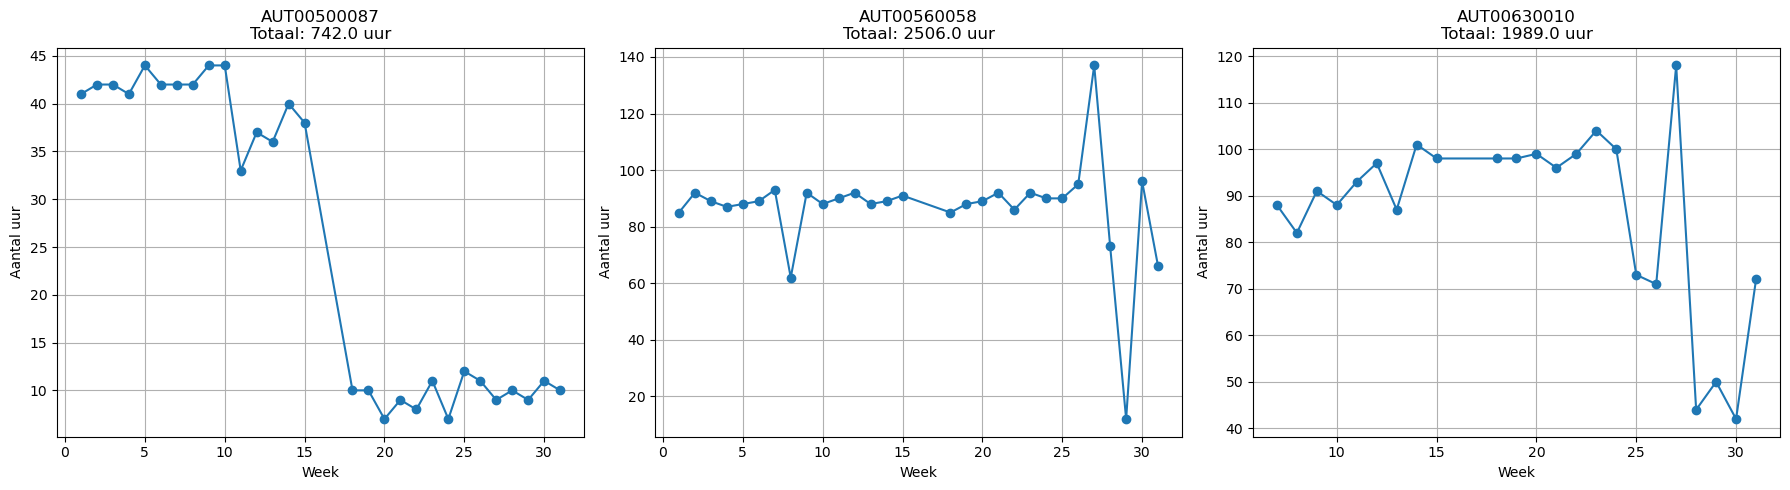

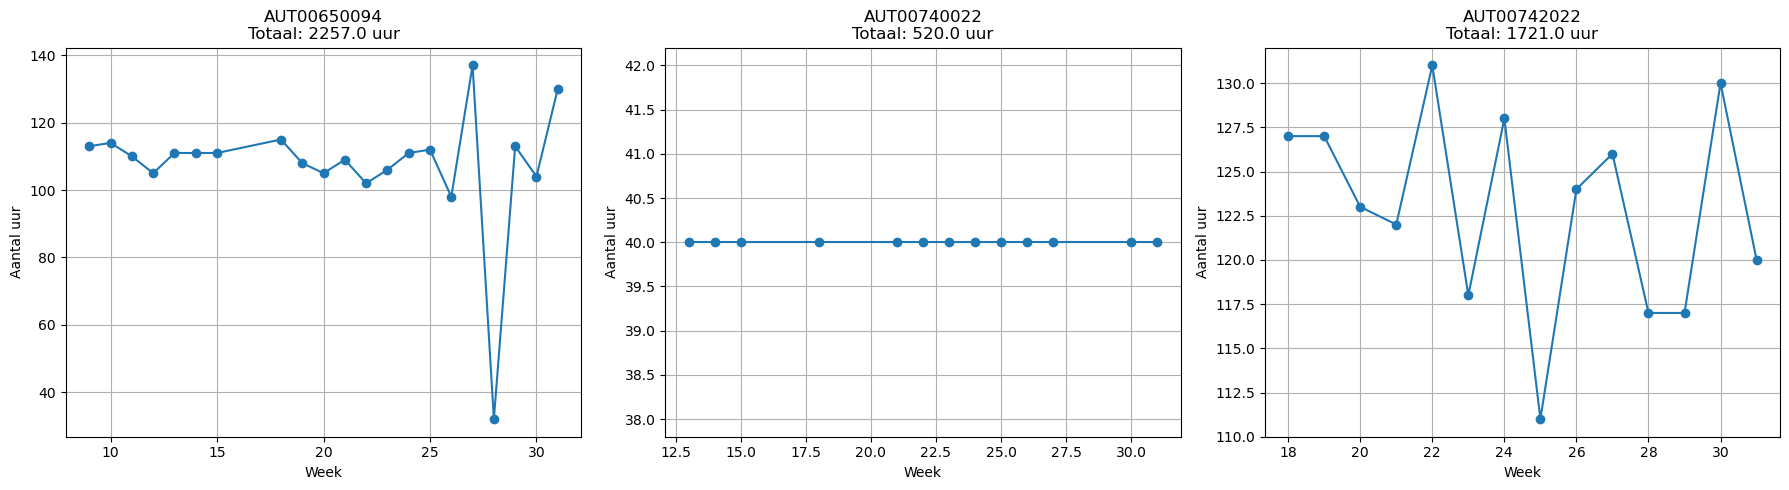

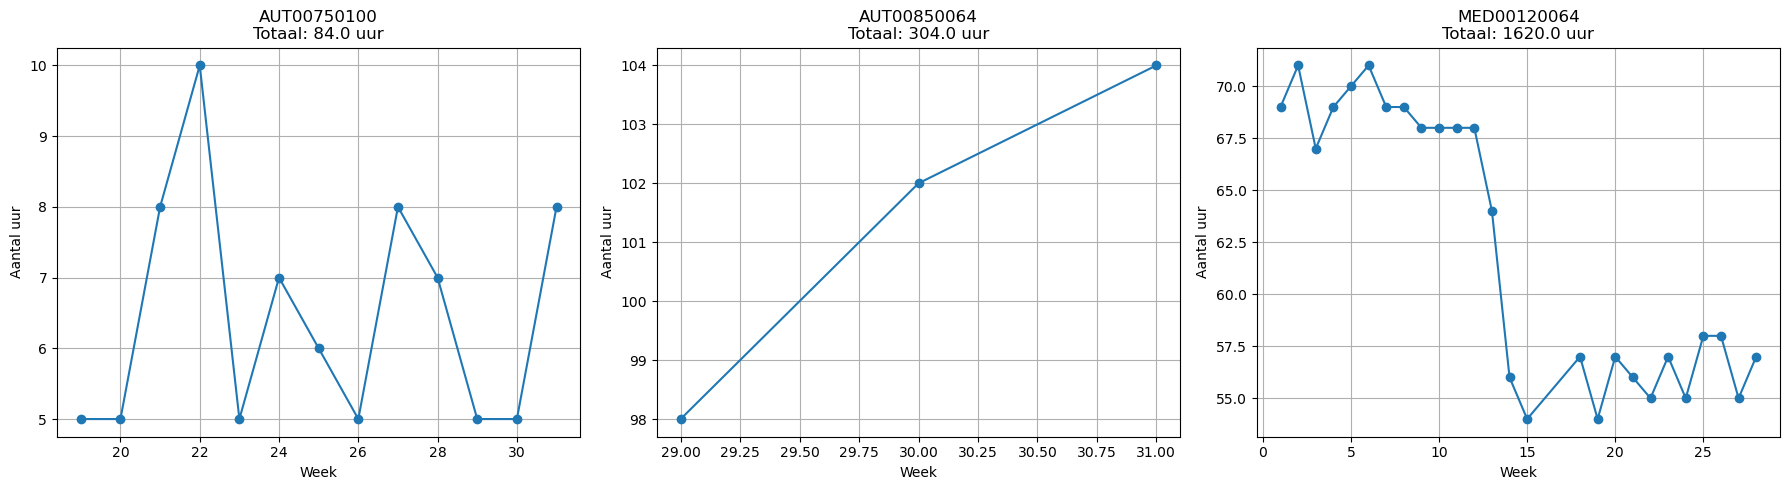

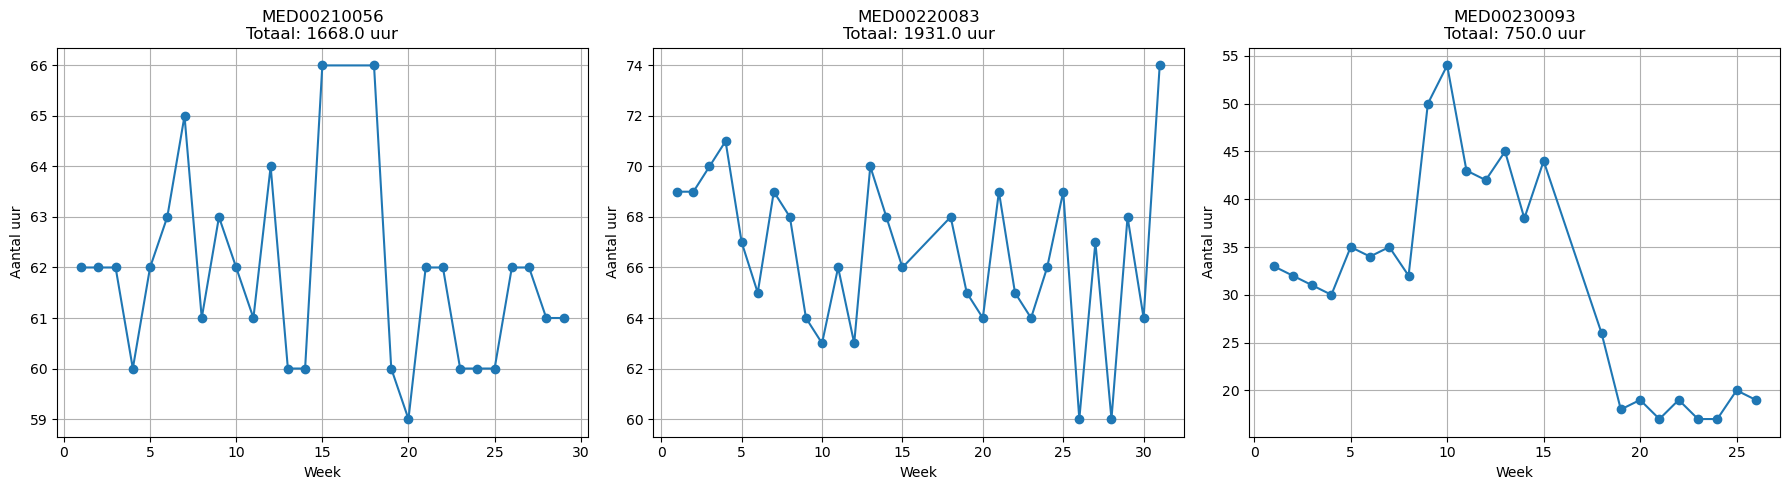

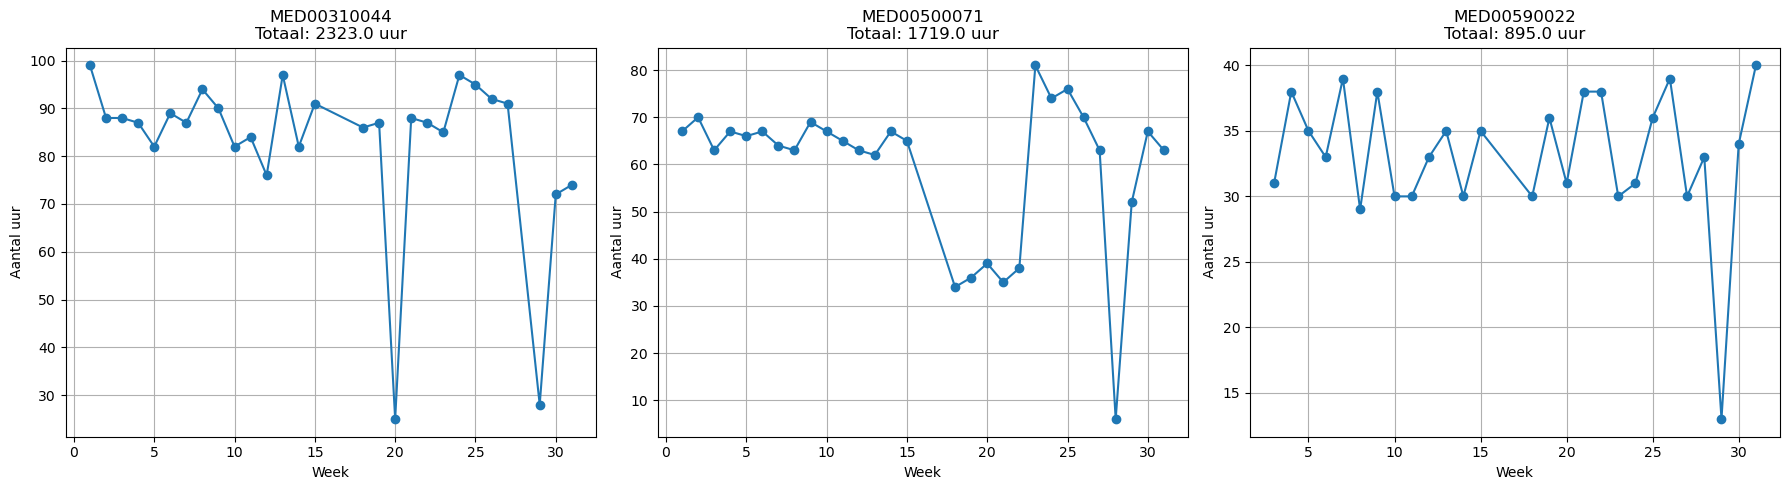

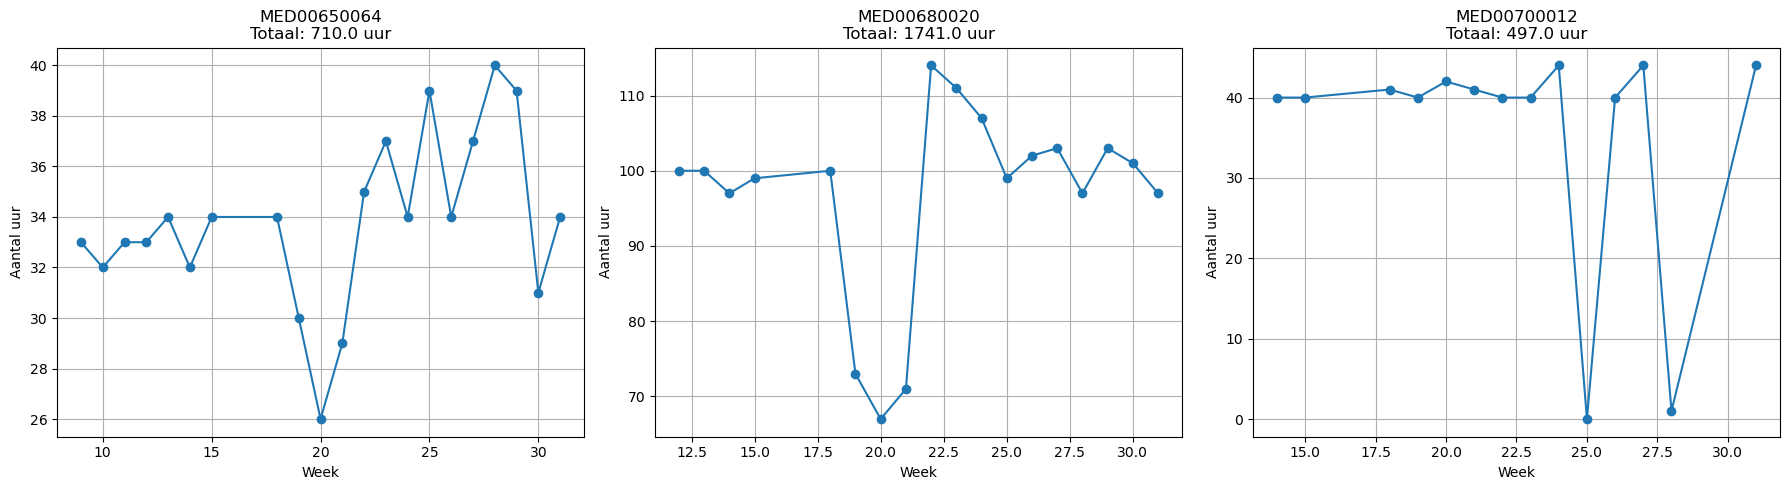

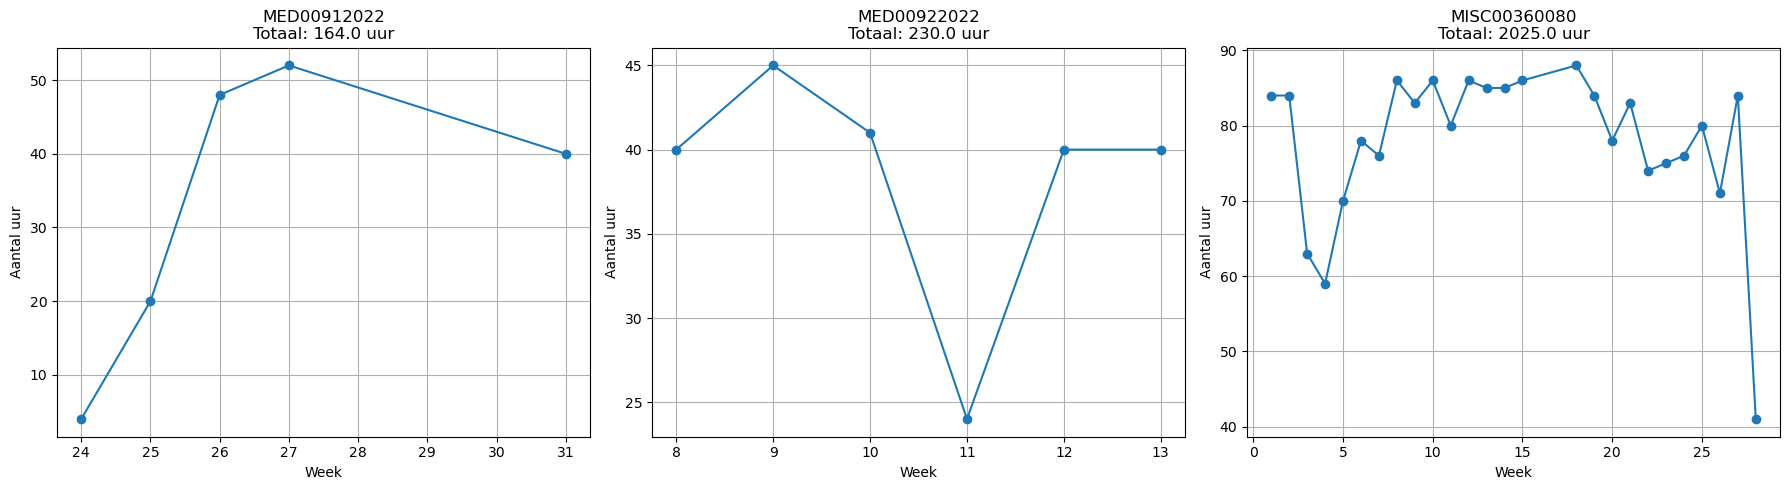

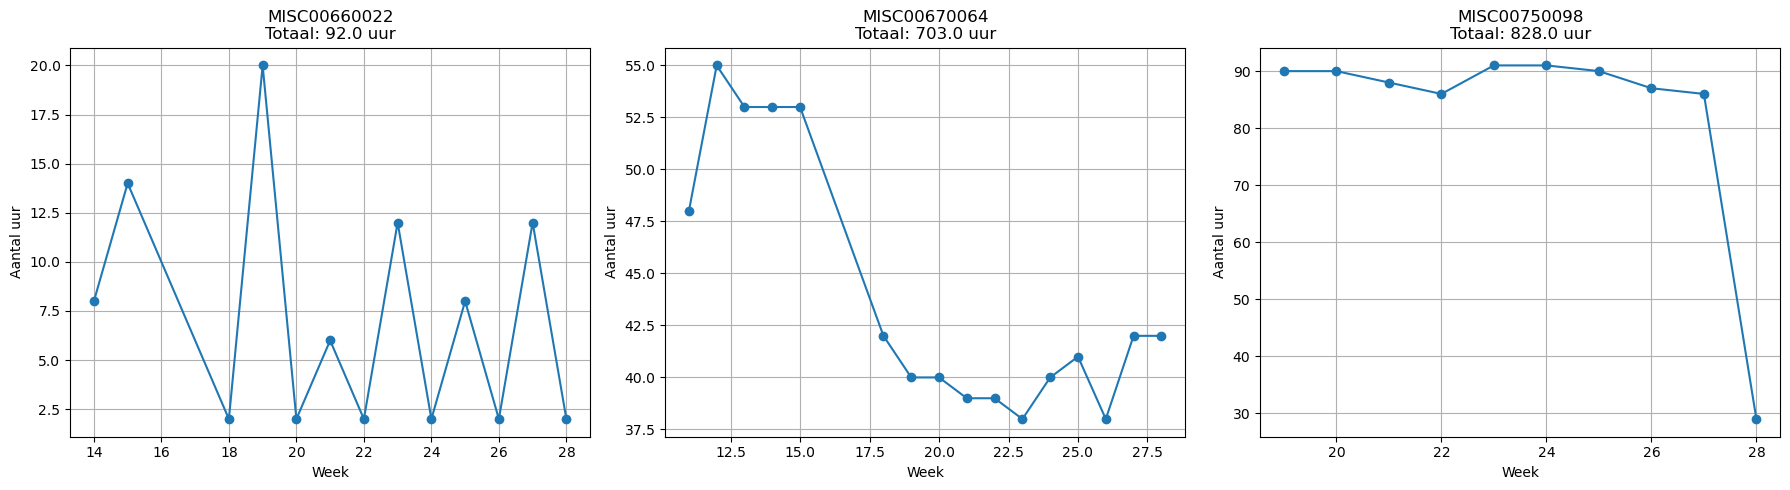

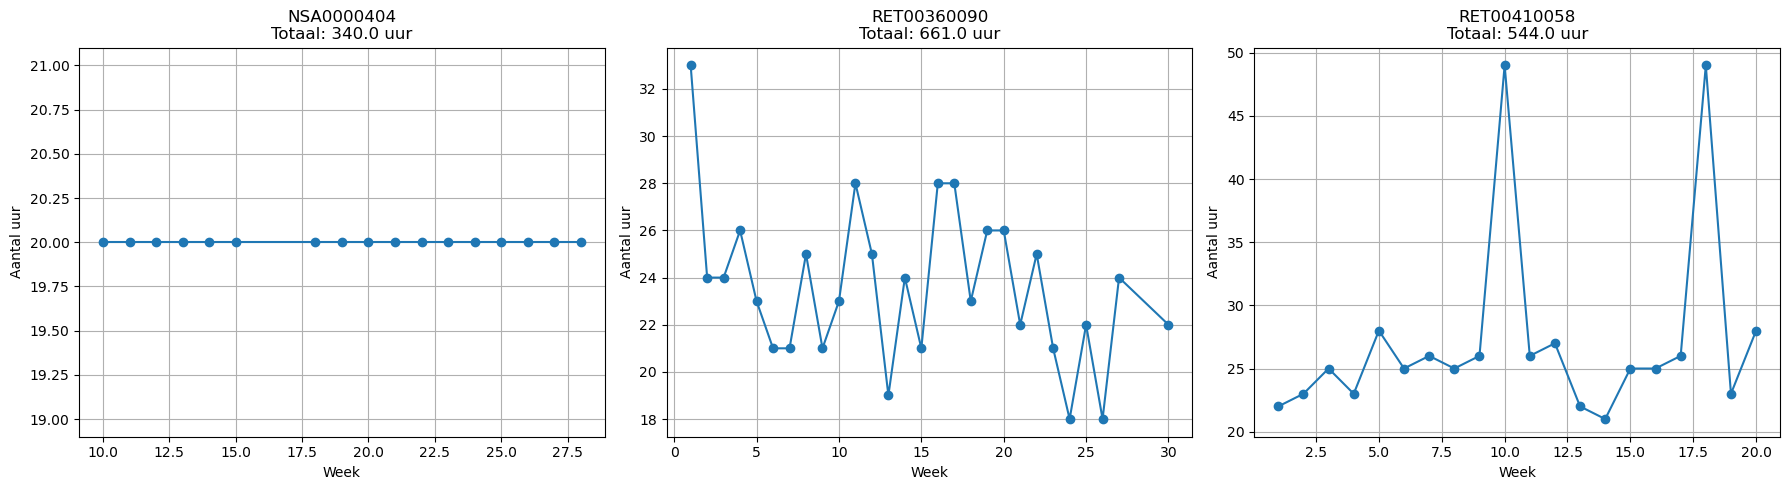

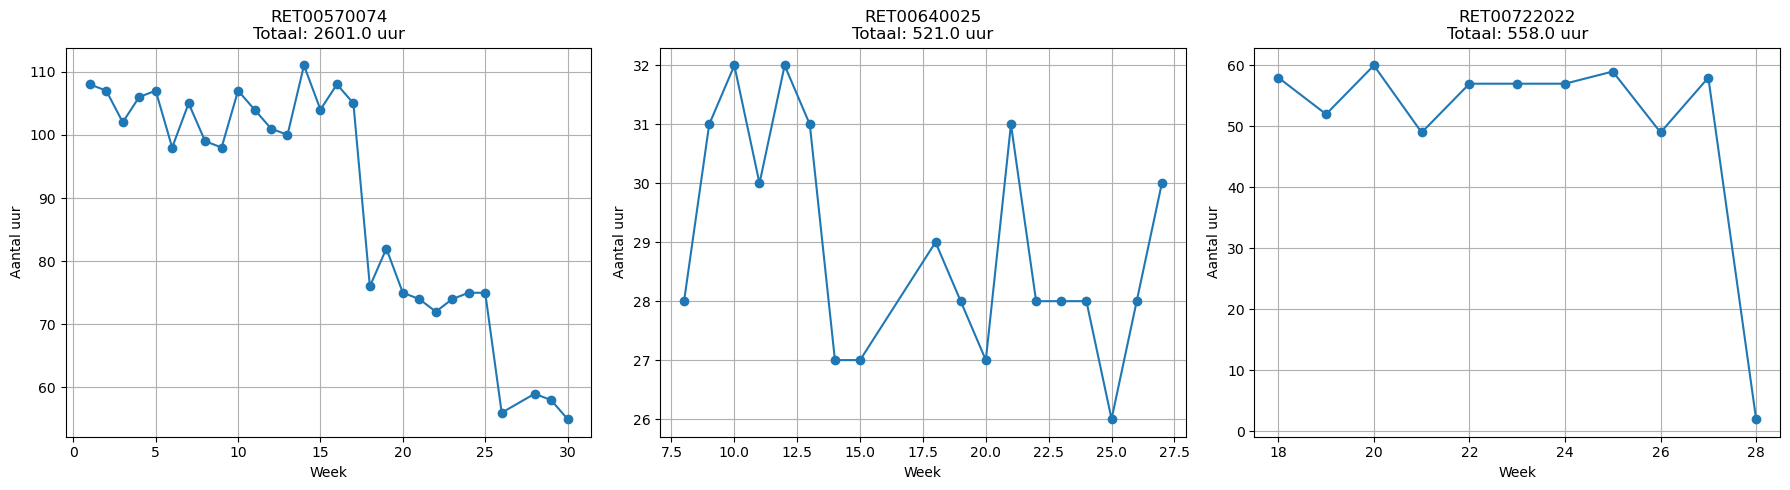

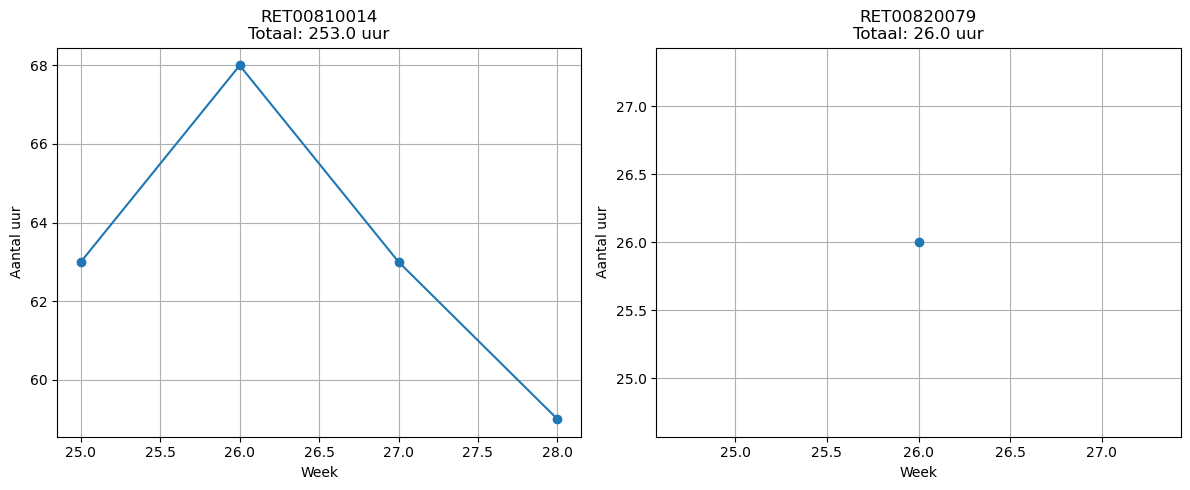

In [5]:
# Uren per project per week optellen
uren_per_week = (
    projecturen
    .groupby(["Project", "Week"])["Hours"]
    .sum()
    .reset_index()
)

projecten = uren_per_week["Project"].unique()

# Steeds 3 projecten tegelijk
for i in range(0, len(projecten), 3):

    drie_projecten = projecten[i:i+3]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for j, project in enumerate(drie_projecten):

        data_project = uren_per_week[
            uren_per_week["Project"] == project
        ]

        totaal_uren = data_project["Hours"].sum()

        axes[j].plot(
            data_project["Week"],
            data_project["Hours"],
            marker="o"
        )

        axes[j].set_title(
            f"{project}\nTotaal: {totaal_uren:.1f} uur"
        )

        axes[j].set_xlabel("Week")
        axes[j].set_ylabel("Aantal uur")
        axes[j].grid(True)

    # Als de laatste rij minder dan 3 projecten bevat,
    # lege grafieken verwijderen
    for j in range(len(drie_projecten), 3):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()